# Classical Machine Learning Model Analysis and Tuning
This notebook covers the detailed evaluation of the two distinguished model from the previous notebook (SVM and RF), followed by fine-tuning process.


In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
import json



## Environment Setup

In [17]:
!git clone https://github.com/qu1r0ra/jute-disease-detection.git
%cd jute-disease-detection

%pip install uv
!uv pip install --system -e .
!uv sync

Cloning into 'jute-disease-detection'...
remote: Enumerating objects: 1396, done.
remote: Counting objects: 100% (531/531), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 1396 (delta 398), reused 314 (delta 282), pack-reused 865 (from 1)
Receiving objects: 100% (1396/1396), 81.36 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (740/740), done.
/content/jute-disease-detection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 55.2 MB/s eta 0:00:00:00:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 132 packages in 1.20s                                       
Prepared 34 packages in 7.12s                                            
Uninstalled 16 packages in 412ms
Installed 34 packages in 248ms                              
 - albucore==0.0.24
 + albucore==0.0.41
 + albumentationsx==2.0.20
 + bitsandbytes==0.49.2
 + captum==0.7.0
 + comm==0.2.3
 + flask-sqlalchemy==3.1.1
 + hydra-core==1.3.2
 - ipykernel==6.17.1
 + ipykernel==7.2.0
 + jedi==0.19.2


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive
%ls

/content/drive/MyDrive
 2x2.pdf
'Akkord '/
'Akkord Internship Logs.gdoc'
 artifacts/
'artifacts with gabor dumped'/
'Colab Notebooks'/
'CSC701M - Presentation 2- Umali_Immanuel.mp4'
 data.zip
'Endorsement_Umali_Immanuel (1).pdf'
 Endorsement_Umali_Immanuel.pdf
'Fin Aid Contract 2023-2024_Revised May 2 2023.gdoc'
'Fin Aid Contract 2023-2024_Revised May 2 2023.pdf'
 IMG_3203.jpeg
 IMG_3204.jpeg
 IMG_3205.jpeg
 IMG_3206.jpeg
 IMG_6413.png
 IMG_6420.png
 IMG_8026.jpeg
 LBP_Umali_Immanuel.pdf
 ml_baseline_comparison.gsheet
'PSHS-BRC CamNorte Attendance Sheet.gdoc'
'ReplySlip_Umali, Immanuel Z.pdf'
'RF_Umali_Immanuel (1).pdf'
'RF_Umali_Immanuel (2).pdf'
 RF_Umali_Immanuel.pdf
'Screenshot 2024-01-08 at 4.17.01 PM.png'
 sfa_vicmap.pdf
 Umali_Certificate-of-Indigency.pdf
'Umali_DLSU Scholarship Essay.pdf'
'Umali_Document and Letter of Explanation for Realty Tax Payment.pdf'
'Umali_General Virtual Assistant'/
 Umali_Immanuel.pdf
'Umali, Immanuel - Proof of Enrollment.pdf'
'Umali_Letter of Explan

## IV. EXPERIMENTS AND RESULTS  
### A. Quantitative Performance

We will summarize the performance metrics and visualize the training dynamics for both our SVM and RF models which were trained on handcrafted features (color, LBP, and HOG) with baseline standard scaling applied.

In [4]:
api_key = os.environ.get("WANDB_API_KEY")

if api_key:
    wandb.login(key=api_key)
else:
    print("API key not found.")
    
api = wandb.Api()

project_path = "grade-descent/jute-disease-detection" 
runs = api.runs(project_path)

summary_list = []
for run in runs:
    if (run.config.get("framework") == "sklearn" or "rf" in run.name or "svm" in run.name) and "crafted" in run.config.get("feature_type") and "experiment" in run.tags:
        summary_list.append({
            "Model": run.config.get("classifier", run.name),
            "Feature_Type": run.config.get("feature_type", "unknown"),
            "Accuracy": run.summary.get("test_acc"),
            "F1-Score": run.summary.get("test_f1"),
            "Run_ID": run.id
        })

df_ml_comparison = pd.DataFrame(summary_list)

output_path = Path("artifacts/ml_baseline_comparison.csv")
df_ml_comparison.to_csv(output_path, index=False)

print(f"Table saved to: {output_path.absolute()}")
display(df_ml_comparison)

API key not found.


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Table saved to: /content/drive/MyDrive/artifacts/ml_baseline_comparison.csv


,Model,Feature_Type,Accuracy,F1-Score,Run_ID
0,rf,crafted,0.722222,0.674715,a1vp3q52
1,svm,crafted,0.669444,0.680710,5g1zzwvm


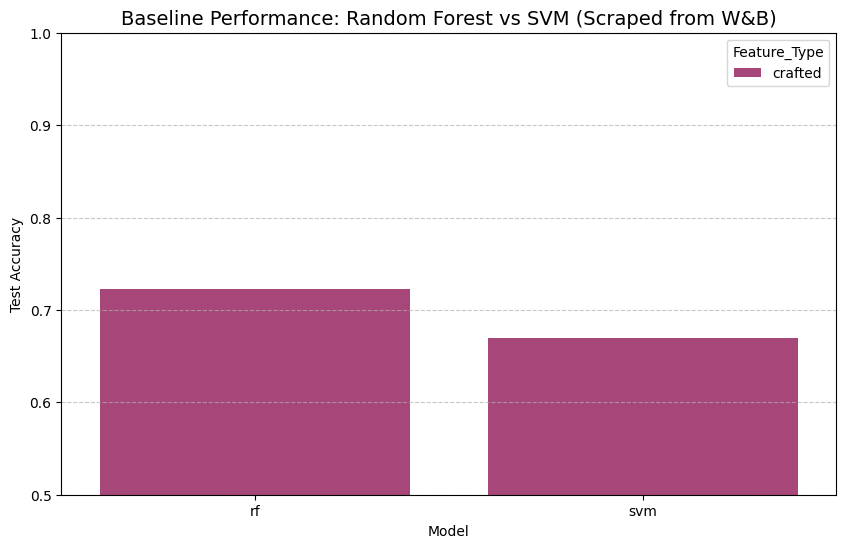

,Model,Feature_Type,Accuracy,F1-Score
0,rf,crafted,0.722222,0.674715
1,svm,crafted,0.669444,0.680710


In [5]:
# 1. Load the specific CSV you just generated from W&B
ml_metrics_path = Path("artifacts/ml_baseline_comparison.csv")

if ml_metrics_path.exists():
    df_ml = pd.read_csv(ml_metrics_path)
    
    # 2. Filter for your two specific baselines (RF and SVM)
    # This ensures we only plot the models relevant to your Phase 1 report
    comparison_models = ["rf", "svm"]
    comp_df = df_ml[df_ml["Model"].str.lower().isin(comparison_models)].copy()
    
    # 3. Visualization: Model vs Accuracy
    plt.figure(figsize=(10, 6))
    
    # Note: Using 'Feature_Type' as the hue to match your scraping script's output
    sns.barplot(
        data=comp_df, 
        x="Model", 
        y="Accuracy", 
        hue="Feature_Type", 
        palette="magma"
    )
    
    # Standardize the view to highlight the 'Feature Ceiling'
    plt.ylim(0.5, 1.0) 
    plt.title("Baseline Performance: Random Forest vs SVM (Scraped from W&B)", fontsize=14)
    plt.ylabel("Test Accuracy")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    
    # Save the plot back to your symlinked artifacts folder for your report
    plt.savefig("artifacts/ml_baseline_comparison_plot.png")
    plt.show()

    # 4. Display the refined table for your discussion
    display(comp_df[["Model", "Feature_Type", "Accuracy", "F1-Score"]])
else:
    print(f"Error: {ml_metrics_path} not found. Run your scraping script first.")

### B. Error Analysis

We begin by creating a confusion matrix that which will allow us to investigate which disease classes are most often mistaken by the model. 

In [6]:
# Filters for the crafted Rf and SVM runs
rf_crafted_id = df_ml_comparison[
    (df_ml_comparison['Model'].str.lower() == 'rf') & 
    (df_ml_comparison['Feature_Type'] == 'crafted')
]['Run_ID'].values[0]

svm_crafted_id = df_ml_comparison[
    (df_ml_comparison['Model'].str.lower() == 'svm') & 
    (df_ml_comparison['Feature_Type'] == 'crafted')
]['Run_ID'].values[0]

In [7]:
# Fetches and constructs the confusion matrix tables from WANDB 
def get_confusion_df(run_id, model_name):
    api = wandb.Api()
    run = api.run(f"grade-descent/jute-disease-detection/{run_id}")
    
    # Fetch the specific Confusion Matrix Table artifact
    artifacts = run.logged_artifacts()
    table_artifact = [a for a in artifacts if "test_conf_mat_table" in a.name][0]
    table_dir = table_artifact.download()
    
    # Load the JSON data
    json_path = list(Path(table_dir).glob("*.json"))[0]
    with open(json_path, "r") as f:
        table_data = json.load(f)
    
    # 3. Create DF
    df = pd.DataFrame(data=table_data["data"], columns=table_data["columns"])
    
    # Standardize column names
    df = df.rename(columns={
        'Actual': 'Actual', 
        'Predicted': 'Predicted', 
        'nPredictions': f'{model_name}_Count',
    })
    
    return df[['Actual', 'Predicted', f'{model_name}_Count']]

# Run for both models using your established IDs
rf_counts = get_confusion_df(rf_crafted_id, "RF")
svm_counts = get_confusion_df(svm_crafted_id, "SVM")

# Merge into the Final Comparison Table
comparison_table = pd.merge(rf_counts, svm_counts, on=['Actual', 'Predicted'], how='outer').fillna(0)

# Add Status for clear Error Analysis
comparison_table['Status'] = comparison_table.apply(
    lambda x: "CORRECT" if x['Actual'] == x['Predicted'] else "WRONG", axis=1
)

# Sort for better readability
comparison_table = comparison_table.sort_values(by=['Actual', 'Status'], ascending=[True, False])

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


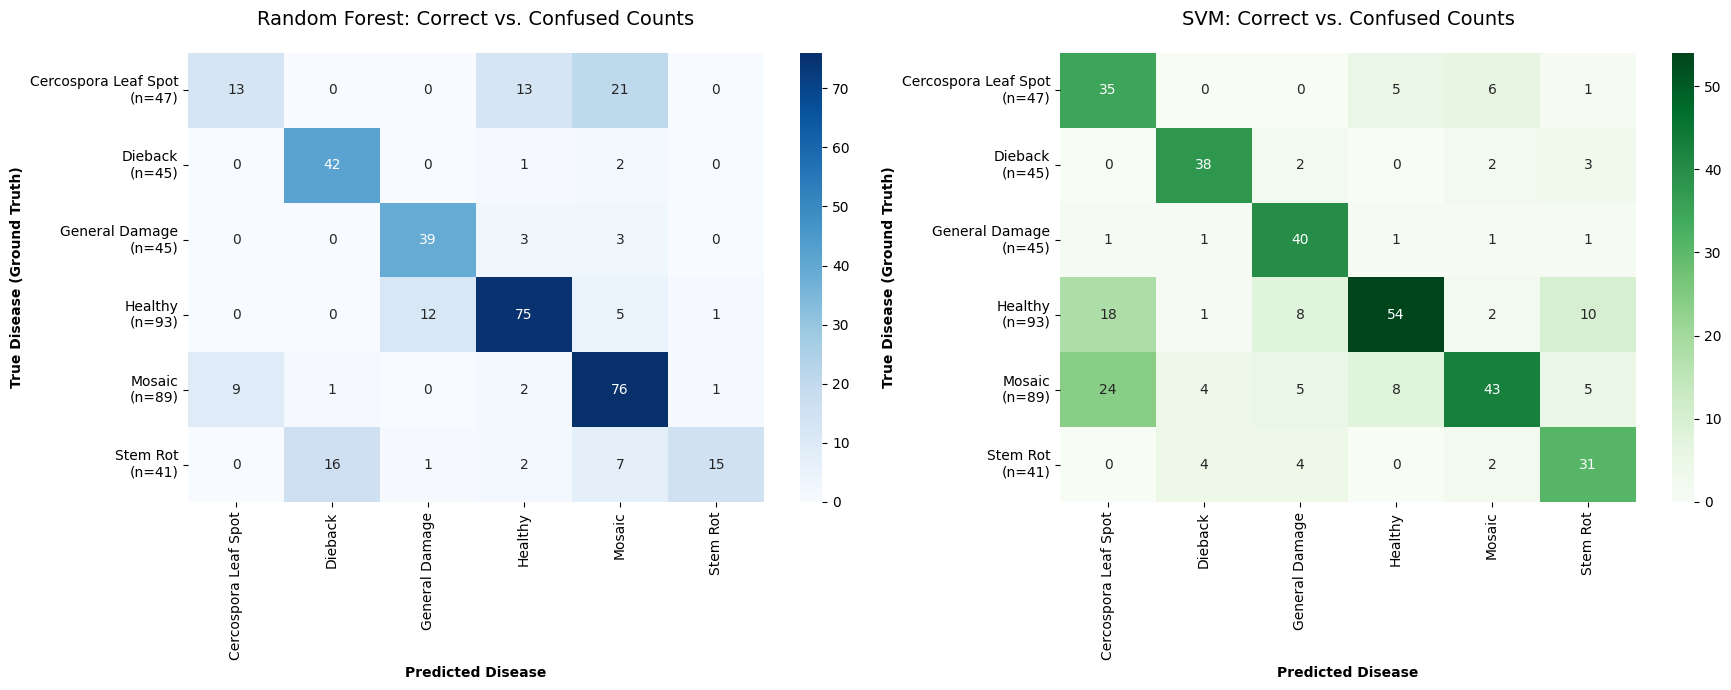

In [8]:
# Confusion matrix visualization setup adopted from: 
# https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn/

def plot_normalized_confusion_matrices(df):
    rf_matrix = df.pivot(index='Actual', columns='Predicted', values='RF_Count').fillna(0)
    svm_matrix = df.pivot(index='Actual', columns='Predicted', values='SVM_Count').fillna(0)
    
    class_totals = rf_matrix.sum(axis=1).astype(int)
    new_labels = [f"{cls}\n(n={total})" for cls, total in class_totals.items()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    sns.heatmap(rf_matrix, annot=True, fmt='g', cmap='Blues', ax=ax1,
                yticklabels=new_labels, xticklabels=rf_matrix.columns)
    ax1.set_title('Random Forest: Correct vs. Confused Counts', fontsize=14, pad=20)
    ax1.set_xlabel('Predicted Disease', fontweight='bold')
    ax1.set_ylabel('True Disease (Ground Truth)', fontweight='bold')

    sns.heatmap(svm_matrix, annot=True, fmt='g', cmap='Greens', ax=ax2,
                yticklabels=new_labels, xticklabels=svm_matrix.columns)
    ax2.set_title('SVM: Correct vs. Confused Counts', fontsize=14, pad=20)
    ax2.set_xlabel('Predicted Disease', fontweight='bold')
    ax2.set_ylabel('True Disease (Ground Truth)', fontweight='bold')

    plt.tight_layout()
    
    plt.savefig("artifacts/ml_confusion_matrix_with_n_counts.png", dpi=300)
    plt.show()

# Run the visualization
plot_normalized_confusion_matrices(comparison_table)

The figures shown above are the visualized confusion matrix for both RF-craft and SVM-crafted. Upon initial inspection of the figures, it appears that the `Healthy` class is often correctly classified as it is distinguished for it high values. 

In order to get a better understanding of the performance of the model classification, we have to look into the accuracy, precision, recall, and F1-score. 

In [9]:
import joblib
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Project-specific imports
from jute_disease.models.ml.features import CraftedFeatureExtractor

# --- CONFIGURATION ---
# Replace these paths with your actual project locations
VAL_DIR = "/content/jute-disease-detection/data/ml_split/val"
TEST_DIR = "/content/jute-disease-detection/data/ml_split/test"
RF_PATH = "/content/drive/MyDrive/artifacts/ml_models/rf_crafted.joblib"
SVM_PATH = "/content/drive/MyDrive/artifacts/ml_models/svm_crafted.joblib"

# 1. Setup Datasets (NumPy-friendly for OpenCV)
ml_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: np.array(x))
])

ml_val = ImageFolder(root=VAL_DIR, transform=ml_transform)
ml_test = ImageFolder(root=TEST_DIR, transform=ml_transform)
pooled_dataset = ml_val + ml_test # This defines pooled_dataset

# 2. Load Models
rf_model = joblib.load(RF_PATH)
svm_model = joblib.load(SVM_PATH)
extractor = CraftedFeatureExtractor()

# 3. Unified Inference
all_rf_preds, all_svm_preds, all_targets = [], [], []

print(f"Running inference on {len(pooled_dataset)} images...")
for img, label in tqdm(pooled_dataset):
    # Extract features once for both models
    feat = extractor.extract(img).reshape(1, -1)
    
    # Predict
    all_rf_preds.append(rf_model.predict(feat)[0])
    all_svm_preds.append(svm_model.predict(feat)[0])
    all_targets.append(label)

# 4. Final Definitions
rf_preds = np.array(all_rf_preds)
svm_preds = np.array(all_svm_preds)
targets = np.array(all_targets)

ModuleNotFoundError: No module named 'jute_disease'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_misclassified_samples(dataset, targets, rf_preds, svm_preds, num_samples=5):
    # 1. Find indices where BOTH models were wrong
    # This identifies the "Ambiguous" images that likely need relabeling
    both_wrong_idx = np.where((rf_preds != targets) & (svm_preds != targets))[0]
    
    if len(both_wrong_idx) == 0:
        print("Wow! No images were misclassified by both models. Checking individual errors...")
        both_wrong_idx = np.where(rf_preds != targets)[0] # Fallback to RF errors

    # 2. Limit the number of samples to display
    display_idx = both_wrong_idx[:num_samples]
    
    # 3. Plotting logic
    fig, axes = plt.subplots(1, len(display_idx), figsize=(20, 5))
    if len(display_idx) == 1: axes = [axes]
    
    classes = ["Healthy", "Mosaic", "Red_Rot", "Stem_Rot"]
    
    for i, idx in enumerate(display_idx):
        # Get the original image (untransformed for better visual inspection)
        # dataset.samples[idx][0] gives the absolute file path
        img_path = dataset.samples[idx][0]
        img = Image.open(img_path)
        
        actual_label = classes[targets[idx]]
        rf_label = classes[rf_preds[idx]]
        svm_label = classes[svm_preds[idx]]
        
        axes[i].imshow(img)
        axes[i].set_title(f"Actual: {actual_label}\nRF: {rf_label}\nSVM: {svm_label}", 
                          color='red', fontsize=10)
        axes[i].axis('off')

    plt.suptitle("Samples Misclassified by Both Models", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Execute for the pooled dataset
# Note: Ensure 'targets', 'preds' (for RF), and 'preds' (for SVM) are already defined 
# from your previous inference run.
display_misclassified_samples(pooled_dataset, targets, rf_preds, svm_preds)

NameError: name 'targets' is not defined

## C. Hyperparameter Tuning


In [24]:
# %cd ..
!git pull
%ls


remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 111.37 KiB | 3.59 MiB/s, done.
From https://github.com/qu1r0ra/jute-disease-detection
   ac420dc..f7bc8d3  eda        -> origin/eda
Updating ac420dc..f7bc8d3
Fast-forward
 .../03_Model_Analysis_Tuning_ML.ipynb              | 585 ++++++++++++++++++++-
 scripts/tune_all_ml.py                             |  98 ++++
 scripts/tune_ml.py                                 |  49 ++
 3 files changed, 730 insertions(+), 2 deletions(-)
 create mode 100644 scripts/tune_all_ml.py
 create mode 100644 scripts/tune_ml.py
AGENTS.md  data/    Makefile        README.md  src/
assets/    docs/    notebooks/      ruff.toml  tests/
configs/   LICENSE  pyproject.toml  scripts/   uv.lock


In [28]:
!uv run python scripts/tune_all_ml.py

2026-03-09 03:01:06,494 - ML_Tuning - INFO - Loading extracted features...
Traceback (most recent call last):
  File "/content/jute-disease-detection/scripts/tune_all_ml.py", line 98, in <module>
    run_tuning()
  File "/content/jute-disease-detection/scripts/tune_all_ml.py", line 22, in run_tuning
    X_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_X.npy")
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/jute-disease-detection/.venv/lib/python3.11/site-packages/numpy/lib/_npyio_impl.py", line 454, in load
    fid = stack.enter_context(open(os.fspath(file), "rb"))
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/features/craftedfeatureextractor_train_X.npy'


## IV. EXPERIMENTS AND RESULTS  
### A. Quantitative Performance

We will summarize the performance metrics and visualize the training dynamics for both our SVM and RF models which were trained on handcrafted features (color, LBP, and HOG) with baseline standard scaling applied. 

## 1. Introduction and Baseline Review
In the previous notebook, we trained a variety of baseline classical machine learning models. The top two performers were the **Random Forest** and **Support Vector Machine (SVM)** trained on handcrafted features (color, LBP, and HOG) with baseline standard scaling applied.

## 2. Error Analysis on Initial Models
Before blindly tuning hyperparameters, it is critical to understand *why* the models make mistakes.
- **Confusion Matrices**: Which disease classes are most often confused?
- **Misclassified Samples**: Visually inspecting images where the models failed. Is it poor lighting? Ambiguous symptoms?
- **Feature Importance**: Using Random Forest's `feature_importances_` to see which crafted features (e.g., LBP vs. HOG) are driving the predictions.

## 3. Hyperparameter Tuning (Grid Search)
To squeeze out maximum performance and mitigate overfitting, we will tune the hyperparameters for both models using Grid Search with Cross-Validation.
- **Random Forest Grid**: `n_estimators`, `max_depth`, `min_samples_split`
- **SVM Grid**: `C` (regularization), `kernel`, `gamma`

## 4. Deep Learning Analysis (Placeholder)
*(This section will be populated in the next phase once our PyTorch Lightning deep learning models are trained and ready for analysis).*